# SEO × Engagement in the AI Search Era

Analysis of how AI-powered search has changed the relationship between SEO performance metrics (Google Search Console) and website engagement (Google Analytics) for `icnachicago.org`.

**Periods**
- Pre-AI: Nov 2024 – Apr 2025 (`AI_period = 0`)
- Post-AI: May 2025 – Oct 2025 (`AI_period = 1`)

**Target (modeling):** daily `sessions`

**Features:** `clicks`, `impressions`, `CTR`, `position`, `AI_period`

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

# Auto-detect where the data files live:
# - Google Colab / plain folder: files sit next to the notebook -> DATA_DIR = '.'
# - Local repo layout:            files live in ./dataset/       -> DATA_DIR = 'dataset'
DATA_DIR = '.' if os.path.exists('ICNA GSC DEC 24 - MAY 25.xlsx') else 'dataset'
OUT_DIR  = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Using DATA_DIR = {DATA_DIR!r}')

RANDOM_STATE = 42

Using DATA_DIR = 'dataset'


## 1. Load datasets

- **GSC (daily):** two Excel files — `Chart` sheet has daily clicks, impressions, CTR, position.
- **GA (daily):** `Events_Event_name (1).csv` — `first_visit` event used as the engagement target.

> **Note on target variable:** `session_start` was only available from 2025-06-09 (post-AI period only), making it unusable for pre/post comparison. `first_visit` covers the full study window (2024-11-01 → 2025-10-31) and is the cleaner SEO metric — it counts brand-new users arriving at the site, which is exactly what organic search drives.

In [2]:
ga_path   = os.path.join(DATA_DIR, 'Events_Event_name (1).csv')
gsc_pre_path  = os.path.join(DATA_DIR, 'ICNA GSC DEC 24 - MAY 25.xlsx')
gsc_post_path = os.path.join(DATA_DIR, 'ICNA GSC JUN 25 - NOV 25.xlsx')

# GSC
gsc_pre  = pd.read_excel(gsc_pre_path,  sheet_name='Chart')
gsc_post = pd.read_excel(gsc_post_path, sheet_name='Chart')
print('GSC pre :', gsc_pre.shape,  gsc_pre['Date'].min(),  '->', gsc_pre['Date'].max())
print('GSC post:', gsc_post.shape, gsc_post['Date'].min(), '->', gsc_post['Date'].max())

# GA — skip the 9 metadata comment lines
ga_raw = pd.read_csv(ga_path, skiprows=9)
print('\nGA events available:')
ga_raw['Date'] = pd.to_datetime(ga_raw['Date'], format='%Y%m%d')
for evt in ga_raw['Event name'].unique():
    sub = ga_raw[ga_raw['Event name'] == evt]
    print(f"  {evt:20s}  rows={len(sub):4d}  {sub['Date'].min().date()} -> {sub['Date'].max().date()}")

GSC pre : (174, 5) 2024-12-09 -> 2025-05-31
GSC post: (183, 5) 2025-06-01 -> 2025-11-30

GA events available:
  session_start         rows= 145  2025-06-09 -> 2025-10-31
  page_view             rows=   1  2025-08-16 -> 2025-08-16
  first_visit           rows= 365  2024-11-01 -> 2025-10-31
  General Donation      rows= 365  2024-11-01 -> 2025-10-31


## 2. Data cleaning & preprocessing

In [3]:
# ── GSC: combine, standardise, add AI_period ─────────────────────────────────
gsc = pd.concat([gsc_pre, gsc_post], ignore_index=True)
gsc.columns = [c.strip().lower() for c in gsc.columns]
gsc['date'] = pd.to_datetime(gsc['date'])
gsc = gsc.sort_values('date').reset_index(drop=True)

def label_period(d):
    if pd.Timestamp('2024-11-01') <= d <= pd.Timestamp('2025-04-30'):
        return 0
    if pd.Timestamp('2025-05-01') <= d <= pd.Timestamp('2025-10-31'):
        return 1
    return np.nan

gsc['AI_period'] = gsc['date'].apply(label_period)
dropped = gsc['AI_period'].isna().sum()
gsc = gsc.dropna(subset=['AI_period']).copy()
gsc['AI_period'] = gsc['AI_period'].astype(int)
print(f'GSC: {len(gsc)} rows kept, {dropped} outside study window dropped')
print('Missing values:\n', gsc.isna().sum())

# ── GA: extract first_visit daily series ─────────────────────────────────────
ga = (ga_raw[ga_raw['Event name'] == 'first_visit']
      [['Date', 'Event count']]
      .rename(columns={'Date': 'date', 'Event count': 'first_visit'})
      .copy())
ga['date'] = pd.to_datetime(ga['date'])
print(f'\nGA first_visit: {len(ga)} daily rows  '
      f'{ga.date.min().date()} -> {ga.date.max().date()}')

# ── MERGE on date ─────────────────────────────────────────────────────────────
df = gsc.merge(ga, on='date', how='inner')
print(f'\nMerged dataset: {df.shape}  '
      f'{df.date.min().date()} -> {df.date.max().date()}')
print('AI_period counts:', df['AI_period'].value_counts().to_dict())

df.to_csv(os.path.join(OUT_DIR, 'merged_dataset.csv'), index=False)
print(f'\nSaved: {OUT_DIR}/merged_dataset.csv')
df.head()

GSC: 327 rows kept, 30 outside study window dropped
Missing values:
 date           0
clicks         0
impressions    0
ctr            0
position       0
AI_period      0
dtype: int64

GA first_visit: 365 daily rows  2024-11-01 -> 2025-10-31

Merged dataset: (327, 7)  2024-12-09 -> 2025-10-31
AI_period counts: {1: 184, 0: 143}

Saved: outputs/merged_dataset.csv


,date,clicks,impressions,ctr,position,AI_period,first_visit
0,2024-12-09,28,964,0.0290,9.6,0,12
1,2024-12-10,43,1186,0.0363,9.2,0,13
2,2024-12-11,44,1343,0.0328,8.2,0,11
3,2024-12-12,51,1418,0.0360,8.8,0,18
4,2024-12-13,72,1379,0.0522,8.1,0,16


## 3. Exploratory Data Analysis (EDA)

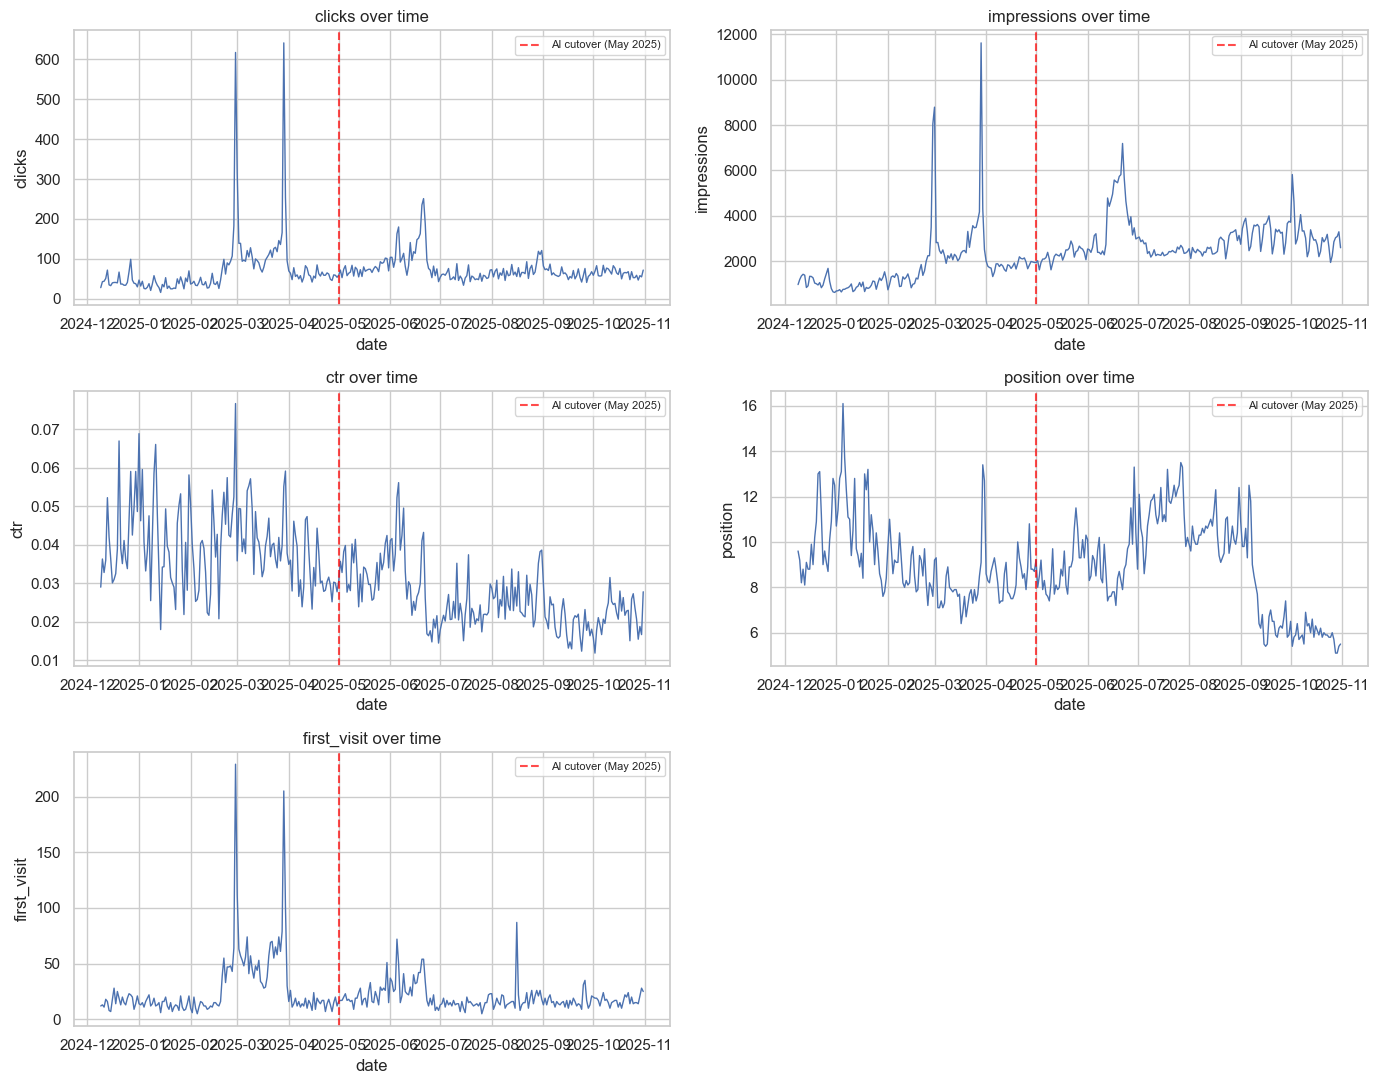

In [4]:
# 3a. Trend plots — all 5 metrics including first_visit
metrics = ['clicks', 'impressions', 'ctr', 'position', 'first_visit']
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
cutover = pd.Timestamp('2025-05-01')
for ax, m in zip(axes.flat, metrics):
    ax.plot(df['date'], df[m], linewidth=1)
    ax.axvline(cutover, color='red', linestyle='--', alpha=0.7, label='AI cutover (May 2025)')
    ax.set_title(f'{m} over time')
    ax.set_xlabel('date')
    ax.set_ylabel(m)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].set_visible(False)   # hide unused 6th panel
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'trend_all_metrics.png'), dpi=150)
plt.show()

In [5]:
# 3b. Pre-AI vs Post-AI grouped mean comparison
comparison = df.groupby('AI_period')[['clicks','impressions','ctr','position','first_visit']].mean().round(3)
comparison.index = ['Pre-AI (0)', 'Post-AI (1)']
pct_change = ((comparison.loc['Post-AI (1)'] - comparison.loc['Pre-AI (0)']) / comparison.loc['Pre-AI (0)'] * 100).round(1)
print("=== Grouped Mean Comparison ===")
print(comparison)
print("\n=== % Change (Post vs Pre) ===")
print(pct_change)
comparison.to_csv(os.path.join(OUT_DIR, 'pre_post_comparison.csv'))
comparison

=== Grouped Mean Comparison ===
             clicks  impressions    ctr  position  first_visit
Pre-AI (0)   72.650     1772.119  0.040     9.183       27.629
Post-AI (1)  73.745     2927.016  0.026     8.849       19.402

=== % Change (Post vs Pre) ===
clicks          1.5
impressions    65.2
ctr           -35.0
position       -3.6
first_visit   -29.8
dtype: float64


,clicks,impressions,ctr,position,first_visit
Pre-AI (0),72.650,1772.119,0.040,9.183,27.629
Post-AI (1),73.745,2927.016,0.026,8.849,19.402


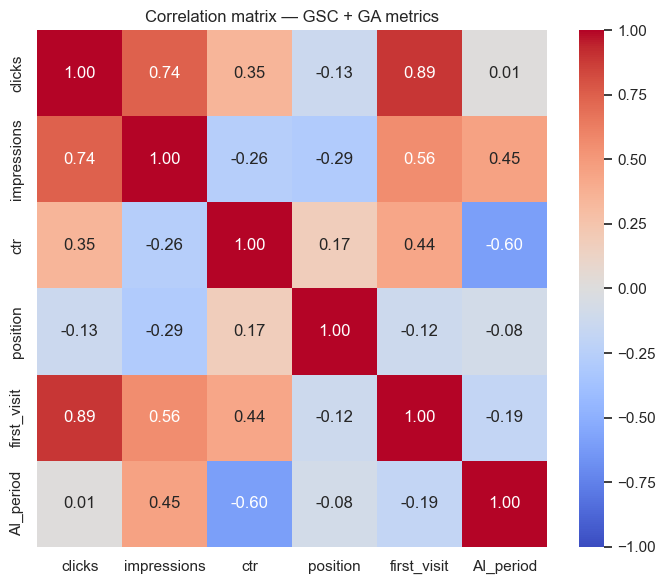

In [6]:
# 3c. Full correlation heatmap — SEO + engagement metrics
corr_cols = ['clicks', 'impressions', 'ctr', 'position', 'first_visit', 'AI_period']
corr = df[corr_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation matrix — GSC + GA metrics')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()

## 4. Machine learning models

> ⚠️ Runs once `df` (GSC + daily GA) is available. The code below is written against that merged frame — activate it by running the GA merge cell in section 2.

In [7]:
features = ['clicks', 'impressions', 'ctr', 'position', 'AI_period']
target   = 'first_visit'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')

# Model 1 — Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Model 2 — Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

def evaluate(model, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return {
        'Model': name,
        'R2'  : round(r2_score(y_test, pred), 4),
        'MAE' : round(mean_absolute_error(y_test, pred), 4),
        'RMSE': round(rmse, 4),
    }

results = pd.DataFrame([evaluate(lr, 'Linear Regression'),
                        evaluate(rf, 'Random Forest')])
results.to_csv(os.path.join(OUT_DIR, 'model_results.csv'), index=False)
print('\n=== Model Evaluation ===')
print(results.to_string(index=False))
results

Train: 261  Test: 66



=== Model Evaluation ===
            Model     R2    MAE    RMSE
Linear Regression 0.8244 7.0982 12.2308
    Random Forest 0.7540 7.3328 14.4774


,Model,R2,MAE,RMSE
0,Linear Regression,0.8244,7.0982,12.2308
1,Random Forest,0.7540,7.3328,14.4774


## 5. Feature importance (Random Forest) + LR coefficients

=== Feature Importance (Random Forest) ===
    feature  importance
     clicks    0.622499
        ctr    0.159298
impressions    0.132977
   position    0.047781
  AI_period    0.037444


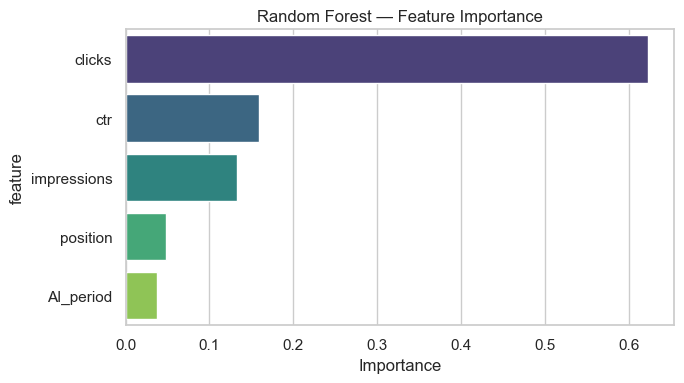


=== Linear Regression Coefficients ===
    feature  coefficient
     clicks       0.4130
impressions      -0.0028
        ctr    -142.9797
   position      -0.4548
  AI_period      -8.0654
(intercept)      12.4117


In [8]:
# Feature importance — Random Forest
imp = (pd.DataFrame({'feature': features, 'importance': rf.feature_importances_})
       .sort_values('importance', ascending=False)
       .reset_index(drop=True))
imp.to_csv(os.path.join(OUT_DIR, 'feature_importance.csv'), index=False)
print('=== Feature Importance (Random Forest) ===')
print(imp.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=imp, x='importance', y='feature', hue='feature',
            palette='viridis', legend=False)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_importance.png'), dpi=150)
plt.show()

# LR coefficients
coefs = pd.DataFrame({'feature': features, 'coefficient': lr.coef_})
coefs = pd.concat([coefs,
                   pd.DataFrame({'feature': ['(intercept)'],
                                 'coefficient': [lr.intercept_]})],
                  ignore_index=True)
coefs['coefficient'] = coefs['coefficient'].round(4)
coefs.to_csv(os.path.join(OUT_DIR, 'lr_coefficients.csv'), index=False)
print('\n=== Linear Regression Coefficients ===')
print(coefs.to_string(index=False))

## 6. Deliverables summary

All outputs saved under `outputs/`:

| File | Description |
|---|---|
| `merged_dataset.csv` | Clean merged GSC + GA daily dataset |
| `pre_post_comparison.csv` | Pre-AI vs Post-AI grouped means |
| `trend_all_metrics.png` | Trend plots for all 5 metrics |
| `correlation_heatmap.png` | Full correlation matrix (SEO + engagement) |
| `model_results.csv` | R², MAE, RMSE for both models |
| `feature_importance.csv` | Random Forest feature importance ranking |
| `feature_importance.png` | Feature importance bar chart |
| `lr_coefficients.csv` | Linear Regression coefficients table |